Confusion Matrix:
 [[1490  143]
 [ 205 1348]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.91      0.90      1633
           1       0.90      0.87      0.89      1553

    accuracy                           0.89      3186
   macro avg       0.89      0.89      0.89      3186
weighted avg       0.89      0.89      0.89      3186


Accuracy: 0.8907721280602636


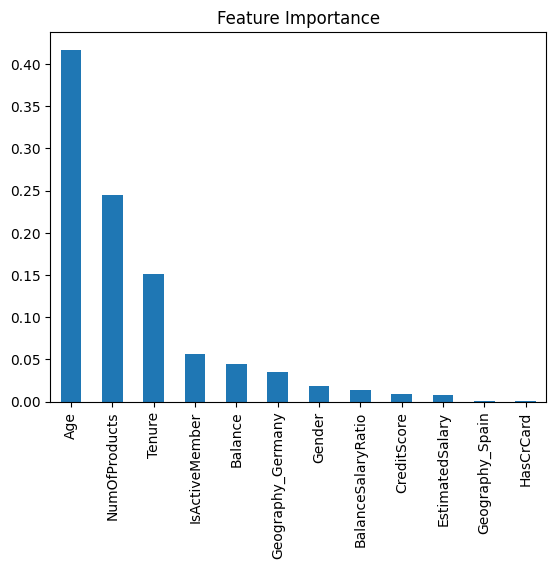

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import GradientBoostingClassifier

from imblearn.over_sampling import SMOTE

data = pd.read_csv('/content/Churn_Modelling.csv')

data = data.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

data = pd.get_dummies(data, columns=['Geography'], drop_first=True)

data['Gender'] = data['Gender'].map({'Female':0, 'Male':1})

data['BalanceSalaryRatio'] = data['Balance'] / (data['EstimatedSalary'] + 1)

X = data.drop(columns=['Exited'])
y = data['Exited']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42
)

model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nAccuracy:", accuracy_score(y_test, y_pred))

feature_importance = pd.Series(model.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=False).plot(kind='bar', title='Feature Importance')

plt.show()